In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import time

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.08MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.44MB/s]


In [4]:
class Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784,512),
            nn.ReLU(),

            nn.Linear(512,256),
            nn.ReLU(),

            nn.Linear(256,20)

        )

    def forward(self,x):

        return self.model(x)

In [5]:
class Decoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(20,256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,784),

            nn.Sigmoid()

        )

    def forward(self,z):

        x = self.model(z)

        return x.view(-1,1,28,28)

In [6]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(20,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,1),

            nn.Sigmoid()

        )

    def forward(self,z):

        return self.model(z)

In [7]:
encoder = Encoder().to(device)

decoder = Decoder().to(device)

discriminator = Discriminator().to(device)

In [8]:
reconstruction_loss = nn.MSELoss()

adversarial_loss = nn.BCELoss()

optimizer_G = optim.Adam(
    list(encoder.parameters()) +
    list(decoder.parameters()),
    lr=0.001
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=0.001
)

In [9]:
epochs = 10

generator_losses = []

discriminator_losses = []

for epoch in range(epochs):

    g_loss_epoch = 0
    d_loss_epoch = 0

    for images,_ in train_loader:

        images = images.to(device)

        batch_size = images.size(0)

        real_labels = torch.ones(batch_size,1).to(device)

        fake_labels = torch.zeros(batch_size,1).to(device)

        # -----------------
        # Train Generator
        # -----------------

        optimizer_G.zero_grad()

        latent = encoder(images)

        reconstructed = decoder(latent)

        recon_loss = reconstruction_loss(
            reconstructed,
            images
        )

        adv_loss = adversarial_loss(
            discriminator(latent),
            real_labels
        )

        generator_loss = recon_loss + 0.001*adv_loss

        generator_loss.backward()

        optimizer_G.step()

        # -----------------
        # Train Discriminator
        # -----------------

        optimizer_D.zero_grad()

        real_latent = torch.randn(batch_size,20).to(device)

        real_loss = adversarial_loss(
            discriminator(real_latent),
            real_labels
        )

        fake_loss = adversarial_loss(
            discriminator(latent.detach()),
            fake_labels
        )

        discriminator_loss = (real_loss + fake_loss)/2

        discriminator_loss.backward()

        optimizer_D.step()

        g_loss_epoch += generator_loss.item()

        d_loss_epoch += discriminator_loss.item()

    generator_losses.append(g_loss_epoch/len(train_loader))

    discriminator_losses.append(d_loss_epoch/len(train_loader))

    print(
        f"Epoch {epoch+1} "
        f"G:{generator_losses[-1]:.4f} "
        f"D:{discriminator_losses[-1]:.4f}"
    )

Epoch 1 G:0.0490 D:0.5920
Epoch 2 G:0.0230 D:0.5861
Epoch 3 G:0.0173 D:0.6615
Epoch 4 G:0.0141 D:0.6624
Epoch 5 G:0.0122 D:0.6509
Epoch 6 G:0.0112 D:0.5683
Epoch 7 G:0.0107 D:0.5410
Epoch 8 G:0.0103 D:0.5192
Epoch 9 G:0.0100 D:0.4983
Epoch 10 G:0.0098 D:0.5049


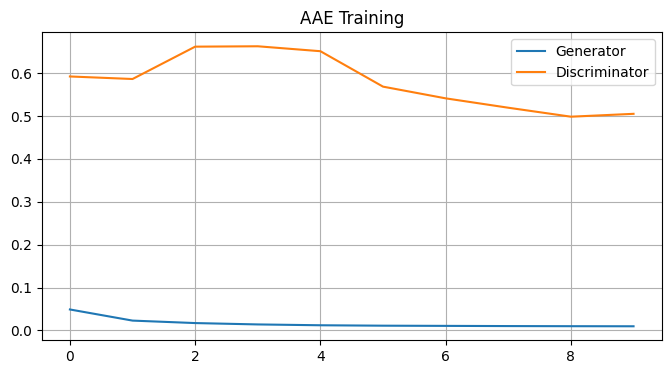

In [10]:
plt.figure(figsize=(8,4))

plt.plot(generator_losses,label="Generator")

plt.plot(discriminator_losses,label="Discriminator")

plt.legend()

plt.grid(True)

plt.title("AAE Training")

plt.show()

In [11]:
encoder.eval()

decoder.eval()

image,_ = next(iter(test_loader))

image = image.to(device)

start = time.time()

with torch.no_grad():

    latent = encoder(image)

    reconstructed = decoder(latent)

end = time.time()

print("Inference Time:",end-start)

Inference Time: 0.0022182464599609375


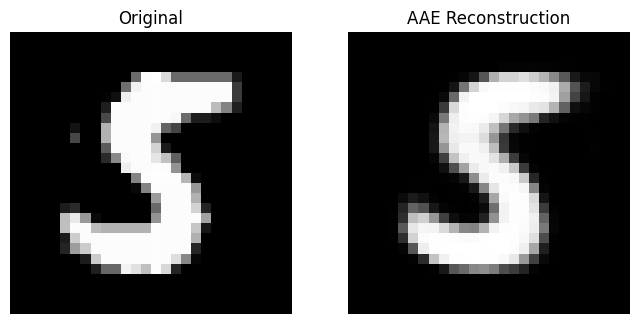

In [12]:
original = image.cpu().squeeze().numpy()

reconstructed = reconstructed.cpu().squeeze().numpy()

plt.figure(figsize=(8,4))

plt.subplot(121)

plt.imshow(original,cmap="gray")

plt.title("Original")

plt.axis("off")

plt.subplot(122)

plt.imshow(reconstructed,cmap="gray")

plt.title("AAE Reconstruction")

plt.axis("off")

plt.show()

In [13]:
mse = np.mean(
    (original-reconstructed)**2
)

print("Reconstruction Error:",mse)

Reconstruction Error: 0.007834848


In [14]:
print("Latent Shape:",latent.shape)

print(latent)

Latent Shape: torch.Size([1, 20])
tensor([[ 1.2515,  0.4575,  0.0584,  0.4536,  0.9148, -1.0915,  0.7887,  2.0914,
         -1.2374,  0.5152, -0.1307,  0.3228, -0.2882, -1.2906,  1.5244,  0.1785,
         -0.8832, -0.7401, -1.2362, -0.1236]])


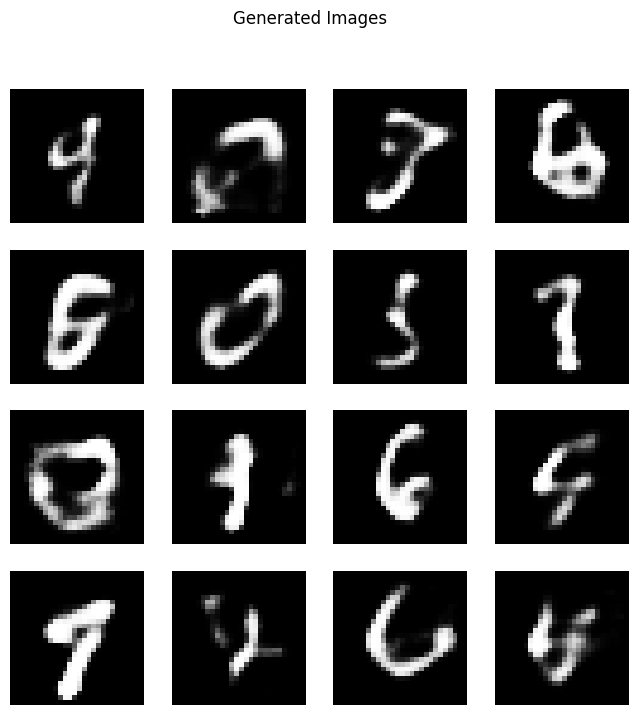

In [15]:
decoder.eval()

with torch.no_grad():

    random_z = torch.randn(16,20).to(device)

    generated = decoder(random_z)

generated = generated.cpu().numpy()

plt.figure(figsize=(8,8))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(generated[i][0],cmap="gray")

    plt.axis("off")

plt.suptitle("Generated Images")

plt.show()